# Post 2 — Analysis & Comparison

Loads saved CV results from `results/post2/cv/` and produces:
1. CV statistical comparisons (paired t-test + Wilcoxon)
2. Holdout evaluation (refits all models on full dev set)
3. Metric disagreement table (benchmarks lie finding)
4. Auction / business value analysis
5. Visualisations
6. Deployment benchmarks

**Prerequisites:**
- `post2_baselines.ipynb` has been run (GLM + GBM results in `results/post2/cv/`)
- `post2_tabpfn.ipynb` has been run (TabPFN results in `results/post2/cv/`) — optional; analysis degrades gracefully without it

In [9]:
import sys, os, json
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from src.data.load_insurance import load_processed, get_dev_holdout
from src.features.insurance_features import RawFeaturePipeline, EngineeredFeaturePipeline, GBMFeaturePipeline
from src.models.glm import TweedieGLM
from src.models.gbm import XGBoostModel, LightGBMModel
from src.evaluation.cv_engine import holdout_evaluation
from src.evaluation.auction import run_all_auctions
from src.evaluation.statistical_tests import compare_models_cv, rank_models_by_metric, metric_disagreement_table

# Auto-discovers every TabPFN experiment subdir (results/post2/cv/<EXPERIMENT_ID>/, ...)
# so this notebook compares all TabPFN library versions side by side. Baseline
# models keep plain names; experiment models are tagged `<model>@<experiment_id>`.
from src.evaluation.experiment_io import (
    discover_experiments, load_all_cv, load_oof,
    load_all_holdout_metrics, load_all_holdout_predictions,
    load_all_benchmarks, write_predictions_all, tag, split_tag,
)

RESULTS_DIR = Path(project_root) / 'results' / 'post2' / 'cv'
FIGURES_DIR = Path(project_root) / 'figures' / 'post2'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENTS = discover_experiments(project_root, 'cv')
print('Imports OK')
print(f'TabPFN experiments discovered: {EXPERIMENTS or "(none yet)"}')


Imports OK
TabPFN experiments discovered: ['tabpfn_v2.6', 'tabpfn_v3.0']


## Step 1 — Load Saved CV Results

In [10]:
# Load every CV fold-metrics file: baselines (flat results/post2/cv/) + all experiment
# subdirs. Baseline keys are plain stems (e.g. "LightGBM_gbm_tweedie"); experiment
# keys are tagged (e.g. "TabPFN_10K_gbm_tweedie@tabpfn_v2.6").
all_cv = load_all_cv(project_root)

# Sanity-check the baseline (tweedie) results that the rest of the notebook needs.
baseline_required = [
    'GLM_Tweedie_raw_tweedie', 'GLM_Tweedie_engineered_tweedie',
    'XGBoost_raw_tweedie', 'XGBoost_engineered_tweedie', 'XGBoost_gbm_tweedie',
    'LightGBM_raw_tweedie', 'LightGBM_engineered_tweedie', 'LightGBM_gbm_tweedie',
]
missing = [k for k in baseline_required if k not in all_cv]
if missing:
    print(f"WARNING: Missing baseline results: {missing}")
    print("Run post2_baselines.ipynb first.")
else:
    print(f"Loaded {len(baseline_required)} baseline (tweedie) CV results")

baseline_models = sorted(k for k in all_cv if split_tag(k)[1] is None)
tabpfn_models   = sorted(k for k in all_cv if split_tag(k)[1] is not None)
print(f"\nTotal CV results loaded: {len(all_cv)}")
print(f"  baseline ({len(baseline_models)}): {baseline_models}")
print(f"  TabPFN   ({len(tabpfn_models)}): {tabpfn_models}")


Loaded 8 baseline (tweedie) CV results

Total CV results loaded: 24
  baseline (12): ['GLM_Tweedie_engineered_tweedie', 'GLM_Tweedie_raw_tweedie', 'GLM_hurdle_engineered_hurdle', 'GLM_hurdle_gbm_hurdle', 'LightGBM_engineered_tweedie', 'LightGBM_gbm_tweedie', 'LightGBM_hurdle_gbm_hurdle', 'LightGBM_raw_tweedie', 'XGBoost_engineered_tweedie', 'XGBoost_gbm_tweedie', 'XGBoost_hurdle_gbm_hurdle', 'XGBoost_raw_tweedie']
  TabPFN   (12): ['TabPFN_10K_engineered_tweedie@tabpfn_v2.6', 'TabPFN_10K_engineered_tweedie@tabpfn_v3.0', 'TabPFN_10K_gbm_tweedie@tabpfn_v2.6', 'TabPFN_10K_gbm_tweedie@tabpfn_v3.0', 'TabPFN_10K_raw_tweedie@tabpfn_v2.6', 'TabPFN_10K_raw_tweedie@tabpfn_v3.0', 'TabPFN_10K_uncalibrated_raw_tweedie@tabpfn_v3.0', 'TabPFN_50K_raw_tweedie@tabpfn_v3.0', 'TabPFN_hurdle_cls_gamma_gbm_hurdle@tabpfn_v2.6', 'TabPFN_hurdle_cls_gamma_raw_hurdle@tabpfn_v3.0', 'TabPFN_hurdle_full_gbm_hurdle@tabpfn_v2.6', 'TabPFN_hurdle_full_raw_hurdle@tabpfn_v3.0']


## Step 2 — CV Rankings

In [11]:
print("=== CV Rankings (Tweedie deviance, lower is better) ===")

pd.set_option("display.expand_frame_repr", False)

rankings = rank_models_by_metric(
    {k: v['fold_metrics'] for k, v in all_cv.items()},
    metric='tweedie_dev_1.5'
)
print(rankings.round(1))

print("\n=== Full mean metrics table ===")

cv_mean_metrics = pd.DataFrame({k: v['mean_metrics'] for k, v in all_cv.items()}).T
cv_mean_metrics = cv_mean_metrics.drop(columns=['mean_s1_prob'], errors='ignore')

summary = cv_mean_metrics.copy()

summary = summary.round({
    'tweedie_dev_1.5': 1,
    'gini': 2,
})

int_cols = ['poisson_dev', 'rmse', 'mae']

paper_cols = ['tweedie_dev_1.5', 'poisson_dev', 'gini', 'rmse', 'mae']

paper_summary = cv_mean_metrics[paper_cols].copy()

formatters = {
    'tweedie_dev_1.5': lambda x: f'{x:.1f}',
    'poisson_dev': lambda x: f'{x:,.0f}' if pd.notna(x) and abs(x) < 1e12 else f'{x:.2e}',
    'gini': lambda x: f'{x:.2f}',
    'rmse': lambda x: f'{x:,.0f}' if pd.notna(x) and abs(x) < 1e12 else f'{x:.2e}',
    'mae': lambda x: f'{x:,.0f}' if pd.notna(x) and abs(x) < 1e12 else f'{x:.2e}',
}

paper_summary = paper_summary.apply(lambda col: col.map(formatters[col.name]))

print(paper_summary)


=== CV Rankings (Tweedie deviance, lower is better) ===
                                                     mean        std    min        max  rank
model                                                                                       
LightGBM_gbm_tweedie                                 79.5        2.7   75.6       84.0     1
LightGBM_raw_tweedie                                 80.1        2.3   77.8       84.3     2
TabPFN_hurdle_full_raw_hurdle@tabpfn_v3.0            80.7        3.2   76.7       86.0     3
TabPFN_hurdle_full_gbm_hurdle@tabpfn_v2.6            81.2        3.9   76.4       87.4     4
LightGBM_hurdle_gbm_hurdle                           81.6        2.0   79.4       84.7     5
TabPFN_hurdle_cls_gamma_raw_hurdle@tabpfn_v3.0       82.8        2.0   80.0       85.0     6
TabPFN_hurdle_cls_gamma_gbm_hurdle@tabpfn_v2.6       82.9        2.3   80.1       85.5     7
LightGBM_engineered_tweedie                          83.6        4.0   79.0       89.9     8
GLM_hurdle_gbm

In [12]:
paper_summary

,tweedie_dev_1.5,poisson_dev,gini,rmse,mae
GLM_Tweedie_engineered_tweedie,90.6,"1,894",0.35,"14,505",501
GLM_Tweedie_raw_tweedie,89.5,"1,875",0.38,"14,505",492
GLM_hurdle_engineered_hurdle,86.2,"1,790",0.35,"14,497",392
GLM_hurdle_gbm_hurdle,85.2,"1,768",0.36,"14,496",389
LightGBM_engineered_tweedie,83.6,"1,767",0.42,"14,512",281
LightGBM_gbm_tweedie,79.5,"1,664",0.43,"14,498",273
LightGBM_hurdle_gbm_hurdle,81.6,"1,718",0.38,"14,496",336
LightGBM_raw_tweedie,80.1,"1,685",0.40,"14,498",273
XGBoost_engineered_tweedie,92.6,"1,841",0.37,"14,602",274
XGBoost_gbm_tweedie,91.2,"1,763",0.42,"14,504",260


## Step 3 — Statistical Comparisons

In [13]:
# Key comparisons for the blog post. Baseline-vs-baseline comparisons are fixed;
# every TabPFN comparison is run once per discovered experiment so versions can be
# compared against the same baselines (and against each other).
comparisons = [
    # Does feature engineering matter for each model type?
    ('GLM_Tweedie_engineered_tweedie', 'GLM_Tweedie_raw_tweedie',   'GLM: eng vs raw'),
    ('XGBoost_gbm_tweedie',            'XGBoost_raw_tweedie',        'XGB: gbm-features vs raw'),
    ('XGBoost_gbm_tweedie',            'XGBoost_engineered_tweedie', 'XGB: gbm-features vs actuarial'),
    ('LightGBM_gbm_tweedie',           'LightGBM_raw_tweedie',       'LGBM: gbm-features vs raw'),
    # Best GBM vs best GLM
    ('LightGBM_gbm_tweedie',           'GLM_Tweedie_engineered_tweedie', 'Best GBM vs Best GLM'),
]

# TabPFN comparisons — one block per experiment.
for exp in EXPERIMENTS:
    comparisons += [
        (tag('TabPFN_10K_gbm_tweedie', exp), 'LightGBM_gbm_tweedie',           f'[{exp}] TabPFN 10K vs Best GBM'),
        (tag('TabPFN_10K_gbm_tweedie', exp), 'GLM_Tweedie_engineered_tweedie', f'[{exp}] TabPFN 10K vs Best GLM'),
        (tag('TabPFN_50K_gbm_tweedie', exp), 'LightGBM_gbm_tweedie',           f'[{exp}] TabPFN 50K vs Best GBM'),
    ]

# Cross-version comparisons: same TabPFN model across consecutive experiments.
for exp_a, exp_b in zip(EXPERIMENTS, EXPERIMENTS[1:]):
    for model in ['TabPFN_10K_gbm_tweedie', 'TabPFN_hurdle_full_gbm_hurdle',
                  'TabPFN_hurdle_cls_gamma_gbm_hurdle']:
        comparisons.append((tag(model, exp_a), tag(model, exp_b),
                            f'{model}: {exp_a} vs {exp_b}'))

for key_a, key_b, label in comparisons:
    if key_a not in all_cv or key_b not in all_cv:
        print(f"  skip {label} (results not loaded)")
        continue
    result = compare_models_cv(
        all_cv[key_a]['fold_metrics'],
        all_cv[key_b]['fold_metrics'],
        metric='tweedie_dev_1.5',
        name_a=key_a, name_b=key_b,
    )
    print(f"[{label}]")
    print(f"  {result['interpretation']}")
    print(f"  Wilcoxon p={result['w_pvalue']:.3f} | {key_a} wins {result['a_wins_n_folds']}/5 folds")
    print()


[GLM: eng vs raw]
  GLM_Tweedie_raw_tweedie has lower mean tweedie_dev_1.5 (90.6096 vs 89.5084, diff=+1.1012). Paired t-test: significant (p=0.002). Note: with n=5 folds, statistical power is limited.
  Wilcoxon p=0.062 | GLM_Tweedie_engineered_tweedie wins 0/5 folds

[XGB: gbm-features vs raw]
  XGBoost_raw_tweedie has lower mean tweedie_dev_1.5 (91.1937 vs 89.7785, diff=+1.4152). Paired t-test: not significant (p=0.575). Note: with n=5 folds, statistical power is limited.
  Wilcoxon p=0.812 | XGBoost_gbm_tweedie wins 3/5 folds

[XGB: gbm-features vs actuarial]
  XGBoost_gbm_tweedie has lower mean tweedie_dev_1.5 (91.1937 vs 92.5775, diff=-1.3838). Paired t-test: not significant (p=0.799). Note: with n=5 folds, statistical power is limited.
  Wilcoxon p=1.000 | XGBoost_gbm_tweedie wins 2/5 folds

[LGBM: gbm-features vs raw]
  LightGBM_gbm_tweedie has lower mean tweedie_dev_1.5 (79.5486 vs 80.0857, diff=-0.5371). Paired t-test: not significant (p=0.282). Note: with n=5 folds, statistic

## Step 4 — Holdout Results

Merges `results/post2/holdout/metrics_baselines.parquet` (from `post2_baselines.ipynb`, run locally)
and `results/post2/holdout/metrics_tabpfn.parquet` (from `post2_tabpfn.ipynb`, run on RunPod).
Analysis proceeds with whatever is available — TabPFN results are optional.

In [14]:
# Merge all holdout metrics: baselines (flat results/post2/holdout/) + every experiment
# subdir. Experiment rows are indexed `<model>@<experiment_id>`.
holdout_results = load_all_holdout_metrics(project_root)
if holdout_results.empty:
    print("No holdout results found. Run post2_baselines.ipynb "
          "(and optionally post2_tabpfn.ipynb) first.")
else:
    print(f"{holdout_results.shape[0]} models total\n")
    print(holdout_results.round(4))


20 models total

                                                 tweedie_dev_1.5  poisson_dev    gini       rmse       mae
model                                                                                                     
GLM_Tweedie_raw_tweedie                             8.960950e+01    1601.2222  0.0995  6256.4334  475.2164
GLM_Tweedie_engineered_tweedie                      9.219690e+01    1644.8101  0.0245  6253.9512  485.2565
XGBoost_raw_tweedie                                 9.267260e+01    1464.8006  0.0823  6242.4014  246.3116
XGBoost_engineered_tweedie                          8.874540e+01    1488.5796  0.1512  6385.3722  263.5122
XGBoost_gbm_tweedie                                 9.083530e+01    1454.8504  0.1283  6237.9750  247.0226
LightGBM_raw_tweedie                                8.228790e+01    1414.7547  0.1274  6239.5271  259.1233
LightGBM_engineered_tweedie                         8.312690e+01    1438.8210  0.0881  6246.5417  265.9064
LightGBM_gbm_tweedie

## Step 5 — Metric Disagreement Table

Using CV mean metrics (more robust than a single holdout draw).

In [16]:
# ranks = metric_disagreement_table(cv_mean_metrics)
# print("Model ranks by metric (1 = best). High rank_std = 'benchmarks lie' effect.")
# ranks

## Step 6 — Auction Analysis

In [17]:
# Load data splits — needed for auction (y_holdout, exp_holdout)
df = load_processed()
splits = get_dev_holdout(df)
X_dev, X_holdout     = splits['X_dev'], splits['X_holdout']
y_dev, y_holdout     = splits['y_dev'], splits['y_holdout']
exp_dev, exp_holdout = splits['exposure_dev'], splits['exposure_holdout']
print(f"Dev: {len(X_dev):,} | Holdout: {len(X_holdout):,} rows")

# Build the consolidated holdout-predictions frame: baseline columns (plain names)
# + every experiment's TabPFN columns (tagged `<model>@<experiment_id>`). Written
# to results/post2/holdout/predictions_all.parquet so run_all_auctions can read it.
preds_df = load_all_holdout_predictions(project_root)
out_path = write_predictions_all(project_root, preds_df)
print(f"Consolidated predictions_all.parquet rebuilt → {out_path.relative_to(project_root)}")
print(f"Columns ({len(preds_df.columns)}): {list(preds_df.columns)}")


Dev: 542,410 | Holdout: 135,603 rows
Consolidated predictions_all.parquet rebuilt → results/post2/holdout/predictions_all.parquet
Columns (20): ['GLM_Tweedie_raw_tweedie', 'GLM_Tweedie_engineered_tweedie', 'XGBoost_raw_tweedie', 'XGBoost_engineered_tweedie', 'XGBoost_gbm_tweedie', 'LightGBM_raw_tweedie', 'LightGBM_engineered_tweedie', 'LightGBM_gbm_tweedie', 'GLM_hurdle_gbm_hurdle', 'XGBoost_hurdle_gbm_hurdle', 'LightGBM_hurdle_gbm_hurdle', 'TabPFN_10K_raw_tweedie@tabpfn_v2.6', 'TabPFN_10K_gbm_tweedie@tabpfn_v2.6', 'TabPFN_hurdle_cls_gamma_gbm_hurdle@tabpfn_v2.6', 'TabPFN_hurdle_full_gbm_hurdle@tabpfn_v2.6', 'TabPFN_10K_raw_tweedie@tabpfn_v3.0', 'TabPFN_10K_eng_tweedie@tabpfn_v3.0', 'TabPFN_10K_uncalibrated_raw_tweedie@tabpfn_v3.0', 'TabPFN_hurdle_cls_gamma_raw_hurdle@tabpfn_v3.0', 'TabPFN_hurdle_full_raw_hurdle@tabpfn_v3.0']


In [18]:
# preds_df was built in the previous cell (baseline + all experiments).
print(f"Predictions: {len(preds_df.columns)} models — {list(preds_df.columns)}")

auction_results = run_all_auctions(
    holdout_results=holdout_results,
    y_holdout=y_holdout['pure_premium'].values,
    exposure_holdout=exp_holdout.values,
)

for matchup, res in auction_results.items():
    agg = res['aggregate']
    print(f"\n{matchup}")
    print(f"  {agg['model_a']}: wins {agg['a_pct_policies']:.1%}, "
          f"loss ratio {agg['a_loss_ratio']:.3f}, profit {agg['a_profit']:,.0f}")
    print(f"  {agg['model_b']}: wins {agg['b_pct_policies']:.1%}, "
          f"loss ratio {agg['b_loss_ratio']:.3f}, profit {agg['b_profit']:,.0f}")


Predictions: 20 models — ['GLM_Tweedie_raw_tweedie', 'GLM_Tweedie_engineered_tweedie', 'XGBoost_raw_tweedie', 'XGBoost_engineered_tweedie', 'XGBoost_gbm_tweedie', 'LightGBM_raw_tweedie', 'LightGBM_engineered_tweedie', 'LightGBM_gbm_tweedie', 'GLM_hurdle_gbm_hurdle', 'XGBoost_hurdle_gbm_hurdle', 'LightGBM_hurdle_gbm_hurdle', 'TabPFN_10K_raw_tweedie@tabpfn_v2.6', 'TabPFN_10K_gbm_tweedie@tabpfn_v2.6', 'TabPFN_hurdle_cls_gamma_gbm_hurdle@tabpfn_v2.6', 'TabPFN_hurdle_full_gbm_hurdle@tabpfn_v2.6', 'TabPFN_10K_raw_tweedie@tabpfn_v3.0', 'TabPFN_10K_eng_tweedie@tabpfn_v3.0', 'TabPFN_10K_uncalibrated_raw_tweedie@tabpfn_v3.0', 'TabPFN_hurdle_cls_gamma_raw_hurdle@tabpfn_v3.0', 'TabPFN_hurdle_full_raw_hurdle@tabpfn_v3.0']
Auction using predictions from: predictions_all.parquet
Available models: ['GLM_Tweedie_raw_tweedie', 'GLM_Tweedie_engineered_tweedie', 'XGBoost_raw_tweedie', 'XGBoost_engineered_tweedie', 'XGBoost_gbm_tweedie', 'LightGBM_raw_tweedie', 'LightGBM_engineered_tweedie', 'LightGBM_gbm_

In [22]:
EXPERIMENTS[0]

'tabpfn_v2.6'

In [24]:
from src.evaluation.auction import auction_analysis
import pandas as pd

# preds_df was built earlier (baseline + all experiments). TabPFN columns are
# tagged `<model>@<experiment_id>`; pick the first discovered experiment here.
_tpfn = tag("TabPFN_hurdle_full_raw_hurdle", EXPERIMENTS[1]) if EXPERIMENTS \
    else "TabPFN_hurdle_full_raw_hurdle"

result = auction_analysis(
    y_true=y_holdout["pure_premium"].values,
    exposure=exp_holdout.values,
    preds_a=preds_df["LightGBM_gbm_tweedie"].values,
    preds_b=preds_df[_tpfn].values,
    name_a="LightGBM_gbm_tweedie",
    name_b=_tpfn,
)

print(f"  {result['model_a']}: wins {result['a_pct_policies']:.1%}, "
        f"loss ratio {result['a_loss_ratio']:.3f}, profit {result['a_profit']:,.0f}")
print(f"  {result['model_b']}: wins {result['b_pct_policies']:.1%}, "
        f"loss ratio {result['b_loss_ratio']:.3f}, profit {result['b_profit']:,.0f}")


  LightGBM_gbm_tweedie: wins 49.5%, loss ratio 2.279, profit -2,090,558
  TabPFN_hurdle_full_raw_hurdle@tabpfn_v3.0: wins 50.5%, loss ratio 2.317, profit -4,167,066


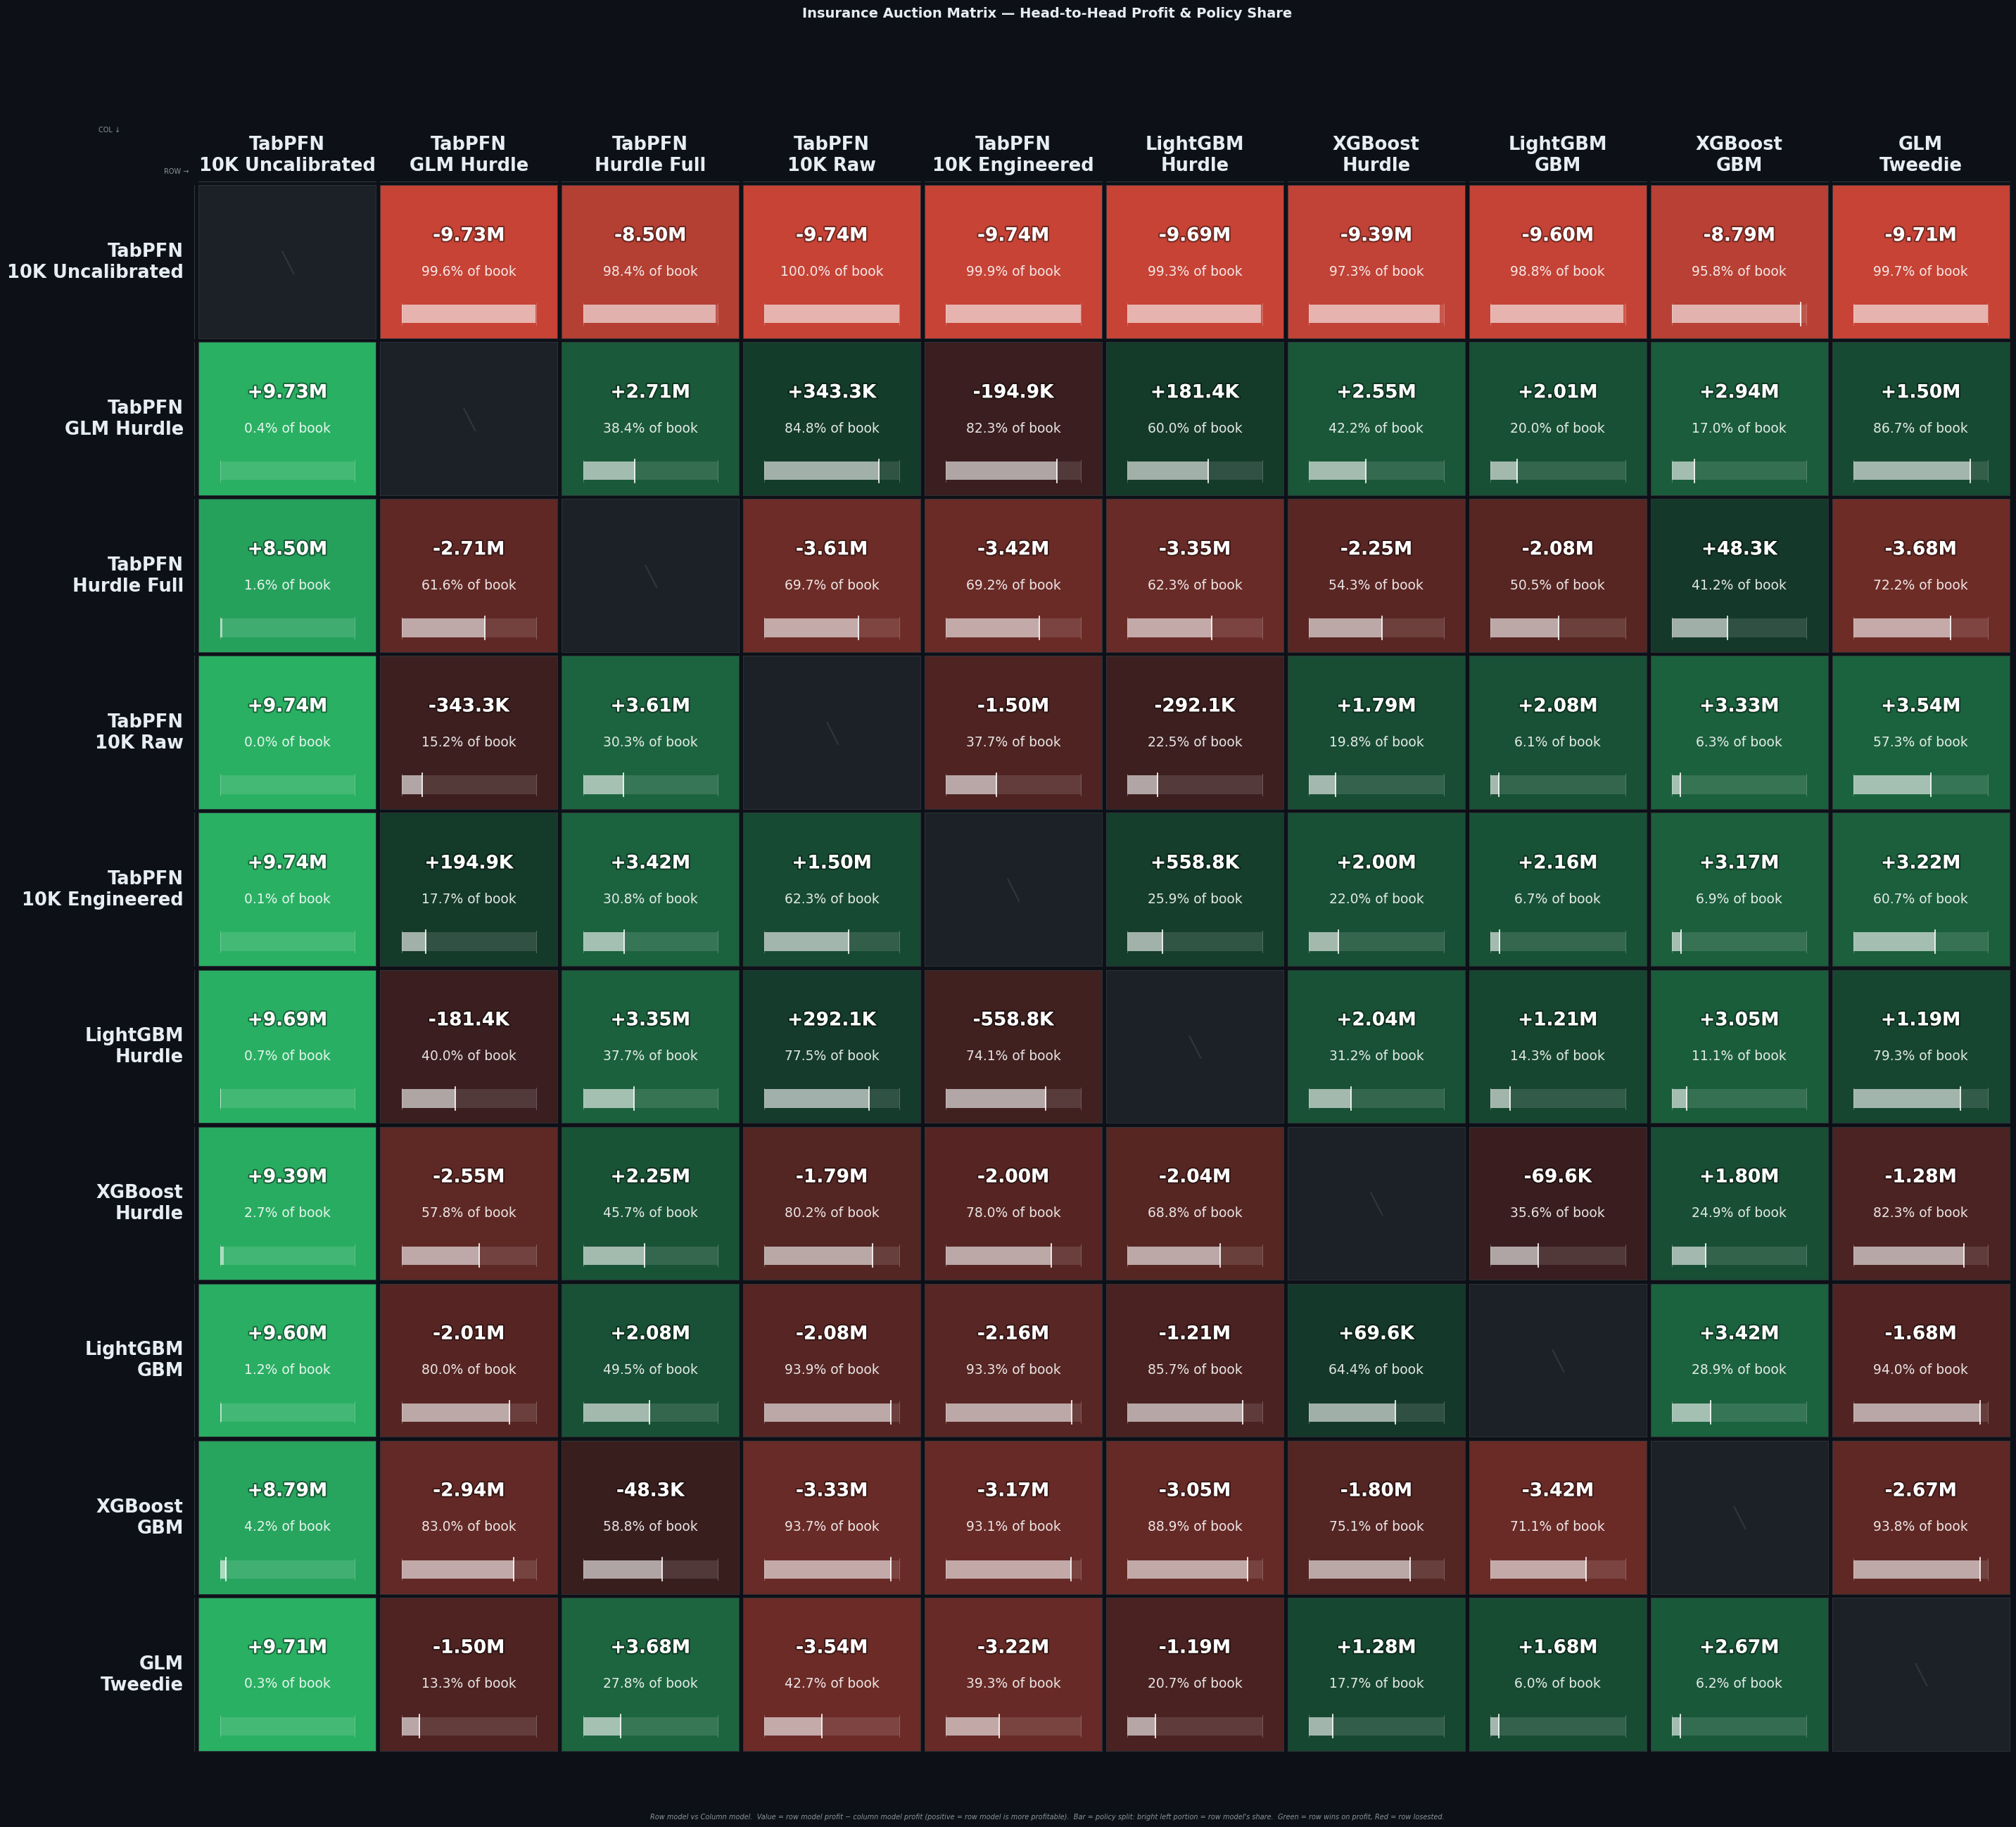

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from src.evaluation.auction import auction_analysis


# ── helpers ───────────────────────────────────────────────────────────────────

def _wrap_label(label: str, max_chars: int = 16) -> str:
    """Wrap long model names at underscores."""
    if len(label) <= max_chars:
        return label
    parts = label.split("_")
    lines, cur = [], ""
    for p in parts:
        candidate = (cur + "_" + p).lstrip("_")
        if cur and len(candidate) > max_chars:
            lines.append(cur)
            cur = p
        else:
            cur = candidate
    if cur:
        lines.append(cur)
    return "\n".join(lines)


def _fmt_profit(profit: float) -> str:
    sign = "+" if profit >= 0 else ""
    if abs(profit) >= 1_000_000:
        return f"{sign}{profit/1_000_000:.2f}M"
    if abs(profit) >= 1_000:
        return f"{sign}{profit/1_000:.1f}K"
    return f"{sign}{profit:.0f}"


# ── main function ─────────────────────────────────────────────────────────────

def plot_auction_matrix(
    model_list: list,
    preds_df=preds_df,
    y_true=y_holdout["pure_premium"].values,
    exposure=exp_holdout.values,
    title: str = "Auction Head-to-Head Matrix",
    cell_size: float = 2.6,
) -> plt.Figure:
    """
    Full N×N auction matrix — row model vs column model.

    Parameters
    ----------
    model_list : ordered list controlling which models appear and in what order.
        Each item is either:
          - a str column name (used as both key and display label), or
          - a (col_name, display_label) tuple for a custom label.
    preds_df   : DataFrame of holdout predictions (columns = model names).
    y_true     : pure-premium ground truth array.
    exposure   : exposure array.
    title      : figure title.
    cell_size  : inches per matrix cell.

    Cell contents
    -------------
    Background colour  green if row model has positive net profit, red otherwise.
                       Intensity scales with magnitude.
    Large text         Net profit (premiums collected − losses paid) on the book
                       the row model writes.
    Small text         % of the total portfolio won by the row model.
    Split bar          Visual policy split: left (bright) = row model share,
                       right (dim) = column model share.
    """
    # ── parse model list ──────────────────────────────────────────────────────
    models = []
    for m in model_list:
        if isinstance(m, (list, tuple)) and len(m) == 2:
            models.append({"col": m[0], "label": m[1]})
        else:
            models.append({"col": m, "label": m})
    n = len(models)
    if n < 2:
        raise ValueError("Need at least 2 models.")

    # ── run all pairwise auctions ─────────────────────────────────────────────
    results = {}
    for i, ma in enumerate(models):
        for j, mb in enumerate(models):
            if i == j:
                continue
            results[(i, j)] = auction_analysis(
                y_true=y_true,
                exposure=exposure,
                preds_a=preds_df[ma["col"]].values,
                preds_b=preds_df[mb["col"]].values,
                name_a=ma["label"],
                name_b=mb["label"],
            )

    # ── colour palette ────────────────────────────────────────────────────────
    BG          = "#0d1117"
    CELL_BG     = "#161b22"
    DIAG_BG     = "#1c2128"
    BORDER      = "#30363d"
    TEXT_BRIGHT = "#e6edf3"
    TEXT_MUTED  = "#8b949e"
    WIN_HEX     = (0x2e / 255, 0xcc / 255, 0x71 / 255)  # #2ecc71
    LOSE_HEX    = (0xe7 / 255, 0x4c / 255, 0x3c / 255)  # #e74c3c
    BG_RGB      = (0.051, 0.071, 0.090)                   # #0d1117

    profits = [results[(i, j)]["a_profit"] - results[(i, j)]["b_profit"] for (i, j) in results]
    max_abs = max(abs(p) for p in profits) if profits else 1.0

    def cell_bg(profit: float):
        t = min(abs(profit) / max_abs, 1.0)
        alpha = 0.20 + 0.65 * t
        base = WIN_HEX if profit >= 0 else LOSE_HEX
        return tuple(BG_RGB[k] + alpha * (base[k] - BG_RGB[k]) for k in range(3))

    # ── figure + gridspec ─────────────────────────────────────────────────────
    # Extra row at top (col headers) and col at left (row headers) + corner cell
    HEADER_W = 1.6   # inches for header column
    HEADER_H = 1.0   # inches for header row
    fig_w = HEADER_W + cell_size * n + 0.3
    fig_h = HEADER_H + cell_size * n + 0.55

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor=BG)
    fig.patch.set_facecolor(BG)

    gs = GridSpec(
        n + 1, n + 1,
        figure=fig,
        width_ratios=[HEADER_W / cell_size] + [1] * n,
        height_ratios=[HEADER_H / cell_size] + [1] * n,
        left=0.01, right=0.99,
        top=0.90, bottom=0.06,
        hspace=0.025, wspace=0.025,
    )

    # ── corner cell ───────────────────────────────────────────────────────────
    ax_corner = fig.add_subplot(gs[0, 0])
    ax_corner.set_facecolor(BG)
    ax_corner.axis("off")
    ax_corner.text(0.95, 0.12, "ROW →", ha="right", va="bottom",
                   fontsize=7, color=TEXT_MUTED, transform=ax_corner.transAxes)
    ax_corner.text(0.12, 0.95, "COL ↓", ha="left", va="top",
                   fontsize=7, color=TEXT_MUTED, transform=ax_corner.transAxes)

    # ── column headers ────────────────────────────────────────────────────────
    for j, m in enumerate(models):
        ax = fig.add_subplot(gs[0, j + 1])
        ax.set_facecolor(BG)
        ax.axis("off")
        # Separator line at bottom of header
        ax.plot([0, 1], [0, 0], color=BORDER, linewidth=0.8, transform=ax.transAxes, clip_on=False)
        ax.text(0.5, 0.45, _wrap_label(m["label"]),
                ha="center", va="center",
                fontsize=18.5, fontweight="bold",
                color=TEXT_BRIGHT, transform=ax.transAxes,
                multialignment="center")

    # ── row headers ───────────────────────────────────────────────────────────
    for i, m in enumerate(models):
        ax = fig.add_subplot(gs[i + 1, 0])
        ax.set_facecolor(BG)
        ax.axis("off")
        ax.plot([1.0, 1.0], [0, 1], color=BORDER, linewidth=0.8, transform=ax.transAxes, clip_on=False)
        ax.text(0.90, 0.5, _wrap_label(m["label"]),
                ha="right", va="center",
                fontsize=18.5, fontweight="bold",
                color=TEXT_BRIGHT, transform=ax.transAxes,
                multialignment="right")

    # ── matrix cells ─────────────────────────────────────────────────────────
    BAR_X0, BAR_X1 = 0.12, 0.88
    BAR_Y0, BAR_Y1 = 0.10, 0.22
    BAR_W = BAR_X1 - BAR_X0
    BAR_H = BAR_Y1 - BAR_Y0

    for i in range(n):
        for j in range(n):
            ax = fig.add_subplot(gs[i + 1, j + 1])
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_color(BORDER)
                spine.set_linewidth(0.6)

            if i == j:
                ax.set_facecolor(DIAG_BG)
                ax.text(0.5, 0.5, "╲",
                        ha="center", va="center",
                        fontsize=20, color=BORDER,
                        transform=ax.transAxes)
                continue

            res     = results[(i, j)]
            profit  = res["a_profit"] - res["b_profit"]
            pct     = res["a_pct_policies"]
            pstr    = _fmt_profit(profit)

            ax.set_facecolor(cell_bg(profit))

            # ── profit value ──
            ax.text(0.5, 0.67, pstr,
                    ha="center", va="center",
                    fontsize=19, fontweight="bold",
                    color="white",
                    transform=ax.transAxes,
                    path_effects=[
                        pe.withStroke(linewidth=3, foreground=(0, 0, 0, 0.4))
                    ])

            # ── % of book ──
            ax.text(0.5, 0.44, f"{pct:.1%} of book",
                    ha="center", va="center",
                    fontsize=13.5, color="white",
                    alpha=0.88,
                    transform=ax.transAxes)

            # ── policy split bar ──────────────────────────────────────────
            # Background track (full width, dim)
            ax.add_patch(Rectangle(
                (BAR_X0, BAR_Y0), BAR_W, BAR_H,
                transform=ax.transAxes,
                facecolor="white", alpha=0.12,
                edgecolor="none", zorder=2, clip_on=False,
            ))
            # Row-model fill
            if pct > 0:
                ax.add_patch(Rectangle(
                    (BAR_X0, BAR_Y0), BAR_W * pct, BAR_H,
                    transform=ax.transAxes,
                    facecolor="white", alpha=0.55,
                    edgecolor="none", zorder=3, clip_on=False,
                ))
            # Divider tick
            tick_x = BAR_X0 + BAR_W * pct
            if 0.04 < pct < 0.96:
                ax.plot([tick_x, tick_x],
                        [BAR_Y0 - 0.015, BAR_Y1 + 0.015],
                        transform=ax.transAxes,
                        color="white", lw=1.2, zorder=4, clip_on=False)
            # End caps
            ax.plot([BAR_X0, BAR_X0],
                    [BAR_Y0 - 0.01, BAR_Y1 + 0.01],
                    transform=ax.transAxes,
                    color="white", lw=0.6, alpha=0.3, zorder=4, clip_on=False)
            ax.plot([BAR_X1, BAR_X1],
                    [BAR_Y0 - 0.01, BAR_Y1 + 0.01],
                    transform=ax.transAxes,
                    color="white", lw=0.6, alpha=0.3, zorder=4, clip_on=False)

    # ── title & footnote ──────────────────────────────────────────────────────
    fig.suptitle(title, fontsize=14, fontweight="bold",
                 color=TEXT_BRIGHT, y=0.96)

    fig.text(0.5, 0.025,
             "Row model vs Column model.  Value = row model profit − column model profit (positive = row model is more profitable).  "
             "Bar = policy split: bright left portion = row model's share.  Green = row wins on profit, Red = row losested.",
             ha="center", fontsize=7, color=TEXT_MUTED, style="italic",
             wrap=True)

    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Example call — edit `models_to_compare` to change the line-up and order
# ─────────────────────────────────────────────────────────────────────────────

# `preds_df` columns: baseline models keep plain names; TabPFN models from each
# experiment are tagged `<model>@<experiment_id>`. `_exp_col` resolves a TabPFN
# column for an experiment (defaults to the first discovered one). To compare
# TabPFN library versions head-to-head, pass two experiments explicitly.
PRIMARY_EXP = EXPERIMENTS[1] if EXPERIMENTS else None

def _exp_col(model, exp=None):
    """Resolve a TabPFN prediction column name for a given experiment id."""
    return tag(model, exp or PRIMARY_EXP) if PRIMARY_EXP else model

models_to_compare = [
    (_exp_col("TabPFN_10K_uncalibrated_raw_tweedie"),"TabPFN\n10K Uncalibrated"),
    (_exp_col("TabPFN_hurdle_cls_gamma_raw_hurdle"), "TabPFN\nGLM Hurdle"),
    (_exp_col("TabPFN_hurdle_full_raw_hurdle"),      "TabPFN\nHurdle Full"),
    (_exp_col("TabPFN_10K_raw_tweedie"),             "TabPFN\n10K Raw"),
    ("LightGBM_hurdle_gbm_hurdle",                   "LightGBM\nHurdle"),
    ("XGBoost_hurdle_gbm_hurdle",                   "XGBoost\nHurdle"),
    ("LightGBM_gbm_tweedie",                         "LightGBM\nGBM"),
    ("GLM_Tweedie_engineered_tweedie",               "GLM\nTweedie"),
]
# Cross-version example — compare one TabPFN model across two experiments:
#   models_to_compare = [
#       (_exp_col("TabPFN_hurdle_full_gbm_hurdle", "tabpfn_v2.6"), "Hurdle v2.6"),
#       (_exp_col("TabPFN_hurdle_full_gbm_hurdle", "tabpfn_v3.0"), "Hurdle v3.0"),
#   ]
models_to_compare = [m for m in models_to_compare if m[0] in preds_df.columns]

fig = plot_auction_matrix(
    model_list=models_to_compare,
    title="Insurance Auction Matrix — Head-to-Head Profit & Policy Share",
    cell_size=2.6,
)
plt.show()


In [42]:
preds_df.columns

Index(['GLM_Tweedie_raw_tweedie', 'GLM_Tweedie_engineered_tweedie',
       'XGBoost_raw_tweedie', 'XGBoost_engineered_tweedie',
       'XGBoost_gbm_tweedie', 'LightGBM_raw_tweedie',
       'LightGBM_engineered_tweedie', 'LightGBM_gbm_tweedie',
       'GLM_hurdle_gbm_hurdle', 'XGBoost_hurdle_gbm_hurdle',
       'LightGBM_hurdle_gbm_hurdle', 'TabPFN_10K_raw_tweedie@tabpfn_v2.6',
       'TabPFN_10K_gbm_tweedie@tabpfn_v2.6',
       'TabPFN_hurdle_cls_gamma_gbm_hurdle@tabpfn_v2.6',
       'TabPFN_hurdle_full_gbm_hurdle@tabpfn_v2.6',
       'TabPFN_10K_raw_tweedie@tabpfn_v3.0',
       'TabPFN_10K_eng_tweedie@tabpfn_v3.0',
       'TabPFN_10K_uncalibrated_raw_tweedie@tabpfn_v3.0',
       'TabPFN_hurdle_cls_gamma_raw_hurdle@tabpfn_v3.0',
       'TabPFN_hurdle_full_raw_hurdle@tabpfn_v3.0'],
      dtype='object')

## Double Lift Chart

Sorts all policies by the ratio **pred_A / pred_B**, bins into deciles, then plots
mean actual vs mean predicted for both models per bin.

* **Decile 1** — model B prices much higher than model A (B thinks risk is high, A disagrees)  
* **Decile 10** — model A prices much higher than model B (A thinks risk is high, B disagrees)  
* A prediction line that closely tracks the actual line → good calibration in that segment

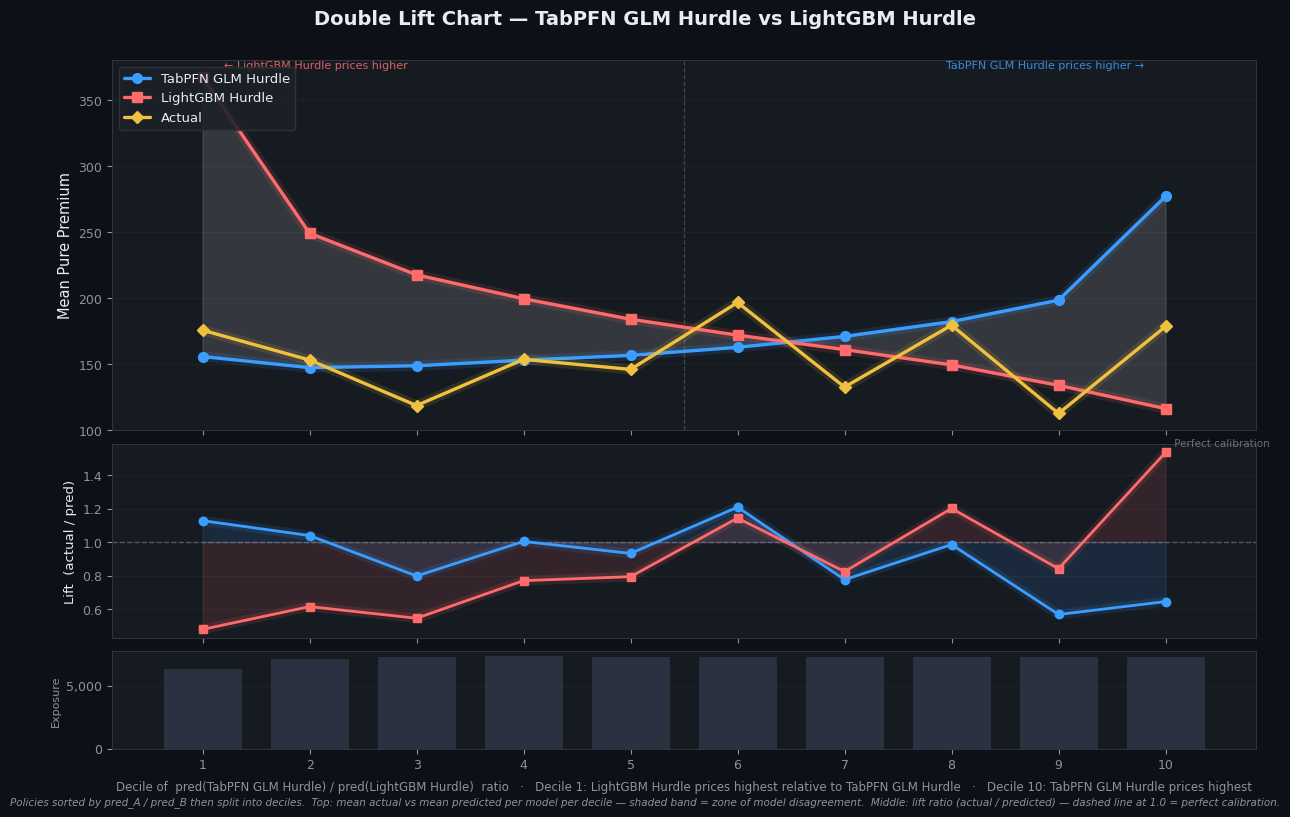

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter


# ── helpers ────────────────────────────────────────────────────────────────────

def _glow(ax, x, y, color, lw, zorder=4, **kw):
    label = kw.pop("label", None)

    ax.plot(
        x, y,
        color=color,
        lw=lw + 5,
        alpha=0.12,
        zorder=zorder - 1,
        solid_capstyle="round",
        label="_nolegend_",
        **kw,
    )

    ax.plot(
        x, y,
        color=color,
        lw=lw,
        zorder=zorder,
        solid_capstyle="round",
        label=label,
        **kw,
    )


def _fmt_k(v, _):
    return f"{int(v / 1_000)}K" if abs(v) >= 1_000 else str(int(v))


# ── main function ──────────────────────────────────────────────────────────────

def plot_double_lift(
    models_to_compare: list,
    preds_df=preds_df,
    y_true=y_holdout["pure_premium"].values,
    exposure=exp_holdout.values,
    n_bins: int = 10,
    title: str = "Double Lift Chart",
) -> plt.Figure:
    """
    Double Lift Chart — head-to-head calibration comparison across prediction-ratio deciles.

    Parameters
    ----------
    models_to_compare : exactly 2 items, each either:
        - a str  (column name, used as display label too), or
        - a (col_name, display_label) tuple
    preds_df   : DataFrame of holdout predictions
    y_true     : pure-premium ground truth array
    exposure   : exposure array (used only to compute annualised actual loss)
    n_bins     : number of bins (default 10 = deciles)
    title      : figure title

    Layout
    ------
    Top panel (main)   — mean actual vs mean pred_A vs mean pred_B per bin.
                         Shaded band between the two predictions highlights
                         disagreement zones.
    Middle panel       — lift ratio: actual / predicted for each model.
                         Value = 1 (dashed line) means perfect calibration.
    Bottom panel       — policy count per bin (how many observations in each bucket).
    """
    if len(models_to_compare) != 2:
        raise ValueError("models_to_compare must have exactly 2 entries.")

    def _parse(m):
        if isinstance(m, (list, tuple)) and len(m) == 2:
            return {"col": m[0], "label": m[1].replace("\n", " ")}
        return {"col": m, "label": m}

    ma = _parse(models_to_compare[0])
    mb = _parse(models_to_compare[1])

    pred_a = preds_df[ma["col"]].values.astype(float)
    pred_b = preds_df[mb["col"]].values.astype(float)

    # Sort by pred_A / pred_B ratio (skip zero-denominator rows)
    denom = np.where(pred_b > 0, pred_b, np.nan)
    ratio = pred_a / denom
    valid = np.isfinite(ratio)

    ratio_v  = ratio[valid]
    actual_v = y_true[valid]
    pred_a_v = pred_a[valid]
    pred_b_v = pred_b[valid]
    exposure_v = exposure[valid]

    # Bin into n_bins quantile buckets by ratio
    bin_idx = pd.qcut(ratio_v, q=n_bins, labels=False, duplicates="drop")

    rows = []
    for b in sorted(set(bin_idx)):
        m = bin_idx == b
        w = exposure_v[m]

        rows.append({
            "bin":        b + 1,
            "n":          int(m.sum()),
            "exposure":   float(w.sum()),
            "ratio_mean": np.average(ratio_v[m], weights=w),
            "actual":     np.average(actual_v[m], weights=w),
            "pred_a":     np.average(pred_a_v[m], weights=w),
            "pred_b":     np.average(pred_b_v[m], weights=w),
        })
    df = pd.DataFrame(rows)
    df["lift_a"] = df["actual"] / df["pred_a"].replace(0, np.nan)
    df["lift_b"] = df["actual"] / df["pred_b"].replace(0, np.nan)

    # ── palette (matches auction matrix dark theme) ────────────────────────
    BG          = "#0d1117"
    PANEL_BG    = "#161b22"
    GRID_COL    = "#21262d"
    BORDER      = "#30363d"
    TEXT_BRIGHT = "#e6edf3"
    TEXT_MUTED  = "#8b949e"
    COL_ACTUAL  = "#f0c040"   # warm gold
    COL_A       = "#3b9eff"   # bright blue  (model A)
    COL_B       = "#ff6b6b"   # coral red    (model B)
    COL_BAR     = "#2a3140"   # dark slate

    lbl_a = ma["label"]
    lbl_b = mb["label"]

    # ── figure ─────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(13, 8.5), facecolor=BG)
    fig.patch.set_facecolor(BG)

    gs = GridSpec(
        3, 1, figure=fig,
        height_ratios=[3.8, 2.0, 1.0],
        hspace=0.06,
        left=0.09, right=0.97,
        top=0.90, bottom=0.09,
    )
    ax_main = fig.add_subplot(gs[0])
    ax_lift = fig.add_subplot(gs[1], sharex=ax_main)
    ax_bar  = fig.add_subplot(gs[2], sharex=ax_main)

    for ax in (ax_main, ax_lift, ax_bar):
        ax.set_facecolor(PANEL_BG)
        ax.tick_params(colors=TEXT_MUTED, labelsize=9)
        for sp in ax.spines.values():
            sp.set_color(BORDER)
            sp.set_linewidth(0.7)
        ax.yaxis.grid(True, color=GRID_COL, linewidth=0.55, zorder=0)
        ax.set_axisbelow(True)

    x = df["bin"].values
    lw = 2.4

    # ── TOP PANEL — absolute pure-premium curves ───────────────────────────
    # Shaded disagreement band between the two model predictions
    ax_main.fill_between(
        x, df["pred_a"].values, df["pred_b"].values,
        alpha=0.13, color="white", zorder=1, label="_nolegend_",
    )
    _glow(ax_main, x, df["pred_a"].values, COL_A,      lw, marker="o", markersize=7,   label=lbl_a, zorder=4)
    _glow(ax_main, x, df["pred_b"].values, COL_B,      lw, marker="s", markersize=7,   label=lbl_b, zorder=4)
    _glow(ax_main, x, df["actual"].values, COL_ACTUAL, lw, marker="D", markersize=6.5, label="Actual",  zorder=5)

    # Midpoint guide
    mid = (x[0] + x[-1]) / 2
    ax_main.axvline(mid, color=TEXT_MUTED, lw=0.9, ls="--", alpha=0.35, zorder=2)

    ax_main.set_ylabel("Mean Pure Premium", color=TEXT_BRIGHT, fontsize=10.5)
    ax_main.tick_params(labelbottom=False)
    ax_main.yaxis.set_major_formatter(FuncFormatter(_fmt_k))

    leg = ax_main.legend(
        frameon=True, framealpha=0.88,
        facecolor="#1c2128", edgecolor=BORDER,
        labelcolor=TEXT_BRIGHT, fontsize=9.5,
        loc="upper left",
    )

    # Directional annotations
    y_top = ax_main.get_ylim()[1]
    ax_main.annotate(
        f"← {lbl_b} prices higher",
        xy=(x[0] + 0.2, y_top), fontsize=8, color=COL_B, alpha=0.85, va="top",
    )
    ax_main.annotate(
        f"{lbl_a} prices higher →",
        xy=(x[-1] - 0.2, y_top), fontsize=8, color=COL_A, alpha=0.85, va="top", ha="right",
    )

    # ── MIDDLE PANEL — lift ratios (actual / predicted) ────────────────────
    ax_lift.axhline(1.0, color=TEXT_MUTED, lw=1.0, ls="--", alpha=0.5, zorder=2)
    ax_lift.fill_between(x, 1.0, df["lift_a"].values, alpha=0.12, color=COL_A, zorder=1)
    ax_lift.fill_between(x, 1.0, df["lift_b"].values, alpha=0.12, color=COL_B, zorder=1)
    _glow(ax_lift, x, df["lift_a"].values, COL_A, lw - 0.4, marker="o", markersize=6, zorder=4)
    _glow(ax_lift, x, df["lift_b"].values, COL_B, lw - 0.4, marker="s", markersize=6, zorder=4)

    ax_lift.set_ylabel("Lift  (actual / pred)", color=TEXT_BRIGHT, fontsize=9.5)
    ax_lift.tick_params(labelbottom=False)
    # Label calibration line
    ax_lift.text(
        x[-1] + 0.05, 1.0, " Perfect calibration",
        va="center", fontsize=7.5, color=TEXT_MUTED, alpha=0.7,
        transform=ax_lift.get_xaxis_transform(),
    )

    # ── BOTTOM PANEL — policy count bars ──────────────────────────────────
    ax_bar.bar(
        x, df["exposure"].values,
        width=0.72,
        color=COL_BAR,
        edgecolor=BORDER,
        linewidth=0.5,
        zorder=2,
    )
    ax_bar.set_ylabel("Exposure", color=TEXT_MUTED, fontsize=8)
    ax_bar.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))

    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels([str(int(b)) for b in x], color=TEXT_MUTED)
    ax_bar.set_xlabel(
        f"Decile of  pred({lbl_a}) / pred({lbl_b})  ratio"
        f"   ·   Decile 1: {lbl_b} prices highest relative to {lbl_a}"
        f"   ·   Decile {int(x[-1])}: {lbl_a} prices highest",
        color=TEXT_MUTED, fontsize=8.5, labelpad=6,
    )

    # ── title + footnote ───────────────────────────────────────────────────
    fig.suptitle(title, fontsize=14, fontweight="bold", color=TEXT_BRIGHT, y=0.96)
    fig.text(
        0.5, 0.025,
        "Policies sorted by pred_A / pred_B then split into deciles.  "
        "Top: mean actual vs mean predicted per model per decile — shaded band = zone of model disagreement.  "
        "Middle: lift ratio (actual / predicted) — dashed line at 1.0 = perfect calibration.",
        ha="center", fontsize=7.5, color=TEXT_MUTED, style="italic",
    )

    plt.tight_layout(rect=[0, 0.04, 1, 0.94])
    return fig

# Edit models_to_compare to select which two models to compare

# `_exp_col` (defined in the auction-matrix cell above) tags a TabPFN model with
# the primary experiment id. Swap in two experiment ids to compare versions.
models_to_compare = [
    (_exp_col("TabPFN_hurdle_cls_gamma_raw_hurdle"), "TabPFN\nGLM Hurdle"),
    ("LightGBM_hurdle_gbm_hurdle",                   "LightGBM\nHurdle"),
]

fig = plot_double_lift(
    models_to_compare=models_to_compare,
    title="Double Lift Chart — TabPFN GLM Hurdle vs LightGBM Hurdle",
    n_bins=10,
)
fig.savefig(FIGURES_DIR / "double_lift_chart.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## Step 7 — Visualisations

Ranking and heatmap use CV mean metrics. Auction plots use holdout.

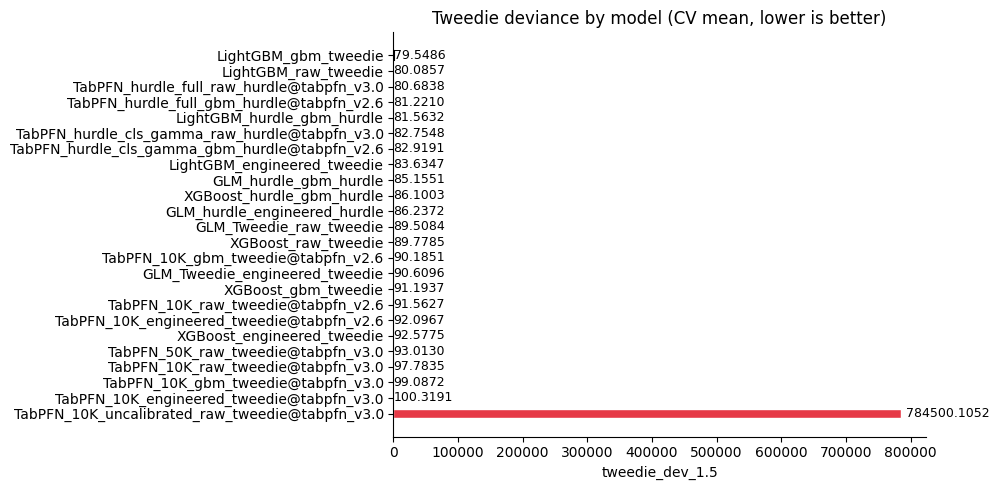

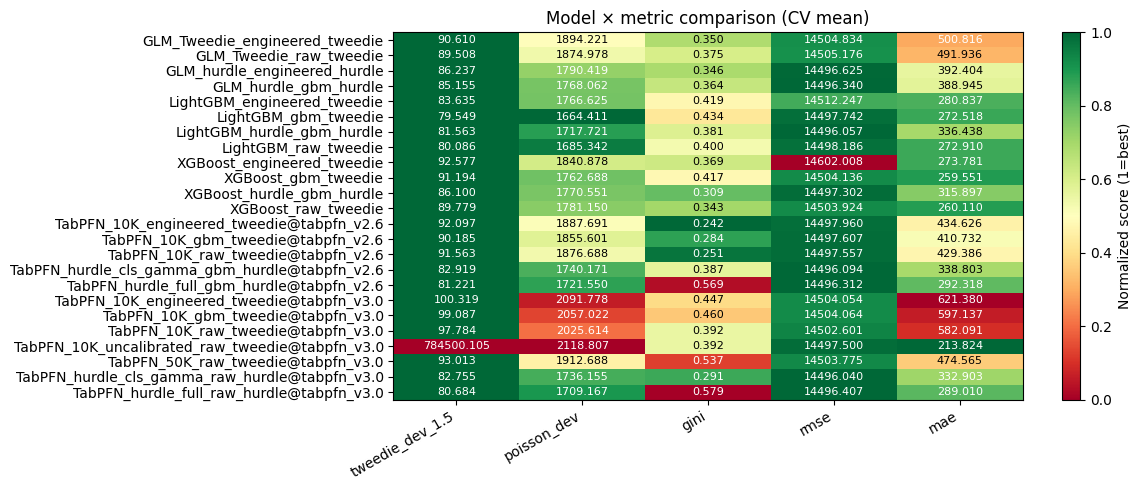

In [39]:
from src.plotting import plot_model_comparison, plot_metrics_heatmap

fig, ax = plot_model_comparison(
    cv_mean_metrics,
    metric='tweedie_dev_1.5',
    title='Tweedie deviance by model (CV mean, lower is better)',
)
fig.savefig(FIGURES_DIR / 'tweedie_deviance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, ax2 = plot_metrics_heatmap(
    cv_mean_metrics,
    metrics=['tweedie_dev_1.5', 'poisson_dev', 'gini', 'rmse', 'mae'],
    title='Model × metric comparison (CV mean)',
)
fig2.savefig(FIGURES_DIR / 'metric_disagreement_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 — Deployment Benchmarks

In [40]:
import time, tracemalloc, pickle

bench_models = [
    ('GLM_Tweedie_eng', TweedieGLM, EngineeredFeaturePipeline),
    ('XGBoost_gbm',     lambda: XGBoostModel(approach='tweedie'), GBMFeaturePipeline),
    ('LightGBM_gbm',    lambda: LightGBMModel(approach='tweedie'), GBMFeaturePipeline),
]

rows = []
for name, model_factory, pipe_cls in bench_models:
    pipe = pipe_cls()
    X_fit = pipe.fit_transform(X_dev.head(50_000), y=y_dev['pure_premium'].head(50_000))
    model = model_factory() if callable(model_factory) else model_factory
    model.fit(X_fit, y_dev['pure_premium'].head(50_000).values,
              exposure=exp_dev.head(50_000).values)

    X_pred = GBMFeaturePipeline().fit_transform(
        X_holdout.head(10_000), y=y_holdout['pure_premium'].head(10_000)) \
        if pipe_cls == GBMFeaturePipeline else \
        EngineeredFeaturePipeline().fit_transform(
            X_holdout.head(10_000), y=y_holdout['pure_premium'].head(10_000))

    times = []
    for _ in range(5):
        t0 = time.perf_counter()
        model.predict(X_pred)
        times.append(time.perf_counter() - t0)

    tracemalloc.start()
    model.predict(X_pred)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    rows.append({
        'model':              name,
        'median_latency_s':   round(np.median(times), 4),
        'peak_memory_mb':     round(peak / 1e6, 1),
        'model_size_mb':      round(len(pickle.dumps(model)) / 1e6, 2),
    })

deploy_dir = Path(project_root) / 'results' / 'post2' / 'deployment'
deploy_dir.mkdir(parents=True, exist_ok=True)

baseline_bench = pd.DataFrame(rows).set_index('model')
baseline_bench.to_parquet(deploy_dir / 'benchmarks_baselines.parquet')

# Merge with every experiment's TabPFN benchmarks (auto-discovered).
bench_df = load_all_benchmarks(project_root)
if bench_df.empty:
    bench_df = baseline_bench
    print("No TabPFN benchmarks found — run Step 8 in post2_tabpfn.ipynb first")
else:
    n_exp = len({split_tag(m)[1] for m in bench_df.index if split_tag(m)[1]})
    print(f"Merged baseline + TabPFN benchmarks from {n_exp} experiment(s)")

print(bench_df)
bench_df.to_parquet(deploy_dir / 'benchmarks.parquet')
print(f"\nSaved → {deploy_dir / 'benchmarks.parquet'}")


Merged baseline + TabPFN benchmarks from 2 experiment(s)
                                     median_latency_s  peak_memory_mb  model_size_mb
model                                                                               
GLM_Tweedie_eng                                0.0001             1.1           7.63
XGBoost_gbm                                    0.0017             0.1           0.40
LightGBM_gbm                                   0.0054             0.2           0.34
TabPFN_10K_raw@tabpfn_v2.6                     8.0759          1927.1          77.78
TabPFN_hurdle_cls_gamma@tabpfn_v2.6            3.3953           613.6           0.00
TabPFN_hurdle_full@tabpfn_v2.6                 5.7907          1653.3           0.00
TabPFN_10K_raw@tabpfn_v3.0                     3.0152          1727.6         243.71
TabPFN_hurdle_cls_gamma@tabpfn_v3.0            2.7602          1059.6           0.00
TabPFN_hurdle_full@tabpfn_v3.0                 4.4976          2386.2           0.00

Saved →